In [24]:
# --- LangChain and LLM Imports ---
from langchain_openai import ChatOpenAI 

# --- Document Loading and Vector Store ---
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

# --- Prompting and Document Utilities ---
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage
from langchain_classic.chains.summarize import load_summarize_chain

# --- Core and Output Parsers ---
from pydantic import BaseModel, Field
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.runnables.graph import MermaidDrawMethod

# --- LangGraph for Workflow Graphs ---
from langgraph.graph import END, StateGraph

# --- Standard Library Imports ---
from time import monotonic
from dotenv import load_dotenv
from pprint import pprint
import tiktoken
import json
import os

# --- Datasets and Typing ---
from datasets import Dataset
from typing_extensions import TypedDict
from IPython.display import display, Image
from typing import List, TypedDict, Dict, Literal

# --- RAGAS Metrics for Evaluation ---
from ragas import evaluate
from ragas.metrics.collections import (
    answer_correctness,
    faithfulness,
    answer_relevancy,
    context_recall,
    SemanticSimilarity
)

import langgraph

# --- Helper Functions ---
from helper_functions import (
    num_tokens_from_string,
    replace_t_with_space,
    replace_double_lines_with_one_line,
    split_into_chapters,
    analyse_metric_results,
    escape_quotes,
    text_wrap,
    extract_book_quotes_as_documents
)
from prompts import (
    keep_only_relevant_content_prompt_template,
    rewrite_prompt_template,
    question_answer_cot_prompt_template,
    is_relevant_content_prompt_template,
    is_grounded_on_facts_prompt_template,
    can_be_answered_prompt_template,
    is_distilled_content_grounded_on_content_prompt_template,
    planner_prompt,
    break_down_plan_prompt_template,
    replanner_prompt_template,
    tasks_handler_prompt_template,
    anonymize_question_prompt_template,
    de_anonymize_plan_prompt_template,
    can_be_answered_already_prompt_template,
)

# --- Load environment variables (e.g., API keys) ---
load_dotenv()
# --- Set environment variable for debugging (optional) ---
os.environ["PYDEVD_WARN_EVALUATION_TIMEOUT"] = "100000"
import warnings
warnings.filterwarnings(
    "ignore", 
    message=".*PydanticSerializationUnexpectedValue.*"
)
warnings.filterwarnings(
    "ignore",
    message="Pydantic serializer warnings:.*",
    category=UserWarning,
)

In [8]:
azure_llm_key = os.getenv("azure_llm_key")
llm = ChatOpenAI(
    model="DeepSeek-V4-Flash",
    base_url="https://3t-ai-resource.services.ai.azure.com/openai/v1",
    api_key=azure_llm_key,
    max_tokens=2048,
    temperature=0.1,
)

In [4]:
embedding_base_url = os.getenv("embedding_base_url")
embedding_key = os.getenv("embedding_key")
embedding_deployment = os.getenv("embedding_deployment")
embeddings = OpenAIEmbeddings(
    model=embedding_deployment,
    base_url=f"{embedding_base_url}/openai/v1",
    api_key=embedding_key,
)

In [5]:
chunks_vector_store = FAISS.load_local("embedding/chunks_vector_store", embeddings, allow_dangerous_deserialization=True)
chapter_summaries_vector_store = FAISS.load_local("embedding/chapter_summaries_vector_store", embeddings, allow_dangerous_deserialization=True)
book_quotes_vectorstore = FAISS.load_local("embedding/book_quotes_vectorstore", embeddings, allow_dangerous_deserialization=True)

In [6]:
# --- Create Query Retrievers from Vector Stores ---
# The following retrievers are used to fetch relevant documents from the vector stores
# based on a query. The number of results returned can be controlled via the 'k' parameter.
# Retriever for book chunks (returns the top 1 most relevant chunk)
chunks_query_retriever = chunks_vector_store.as_retriever(search_kwargs={"k": 5})
# Retriever for chapter summaries (returns the top 1 most relevant summary)
chapter_summaries_query_retriever = chapter_summaries_vector_store.as_retriever(search_kwargs={"k": 2})
# Retriever for book quotes (returns the top 10 most relevant quotes)
book_quotes_query_retriever = book_quotes_vectorstore.as_retriever(search_kwargs={"k": 5})

In [18]:
def retrieve_context_per_question(state):
    """
    Retrieves relevant context for a given question by aggregating content from:
    - Book chunks
    - Chapter summaries
    - Book quotes
    Args:
        state (dict): A dictionary containing the question to answer, with key "question".
    Returns:
        dict: A dictionary with keys:
            - "context": Aggregated context string from all sources.
            - "question": The original question.
    """
    question = state["question"]
    # Retrieve relevant book chunks
    print("Retrieving relevant chunks...")
    docs = chunks_query_retriever.invoke(question)
    context = " ".join(doc.page_content for doc in docs)
    # Retrieve relevant chapter summaries
    print("Retrieving relevant chapter summaries...")
    docs_summaries = chapter_summaries_query_retriever.invoke(question)
    context_summaries = " ".join(
        f"{doc.page_content} (Chapter {doc.metadata['chapter']})" for doc in docs_summaries
    )
    # Retrieve relevant book quotes
    print("Retrieving relevant book quotes...")
    docs_book_quotes = book_quotes_query_retriever.invoke(question)
    book_quotes = " ".join(doc.page_content for doc in docs_book_quotes)
    # Aggregate all contexts and escape problematic characters
    all_contexts = context + context_summaries + book_quotes
    all_contexts = escape_quotes(all_contexts)
    return {"context": all_contexts, "question": question}

In [10]:
# --- LLM-based Function to Filter Only Relevant Retrieved Content ---
# Output schema for the filtered relevant content
class KeepRelevantContent(BaseModel):
    relevant_content: str = Field(
        description="The relevant content from the retrieved documents that is relevant to the query."
    )

# Create the prompt for the LLM
keep_only_relevant_content_prompt = PromptTemplate(
    template=keep_only_relevant_content_prompt_template,
    input_variables=["query", "retrieved_documents"],
)

# Create the LLM chain for filtering relevant content
keep_only_relevant_content_chain = (
    keep_only_relevant_content_prompt
    | llm.with_structured_output(KeepRelevantContent)
)

def keep_only_relevant_content(state):
    """
    Filters and keeps only the relevant content from the retrieved documents that is relevant to the query.
    Args:
        state (dict): A dictionary containing:
            - "question": The query question.
            - "context": The retrieved documents as a string.
    Returns:
        dict: A dictionary containing:
            - "relevant_context": The filtered relevant content.
            - "context": The original context.
            - "question": The original question.
    """
    question = state["question"]
    context = state["context"]
    input_data = {
        "query": question,
        "retrieved_documents": context
    }
    print("Keeping only the relevant content...")
    pprint("--------------------")
    output = keep_only_relevant_content_chain.invoke(input_data)
    relevant_content = output.relevant_content
    relevant_content = "".join(relevant_content)
    relevant_content = escape_quotes(relevant_content)

    return {
        "relevant_context": relevant_content,
        "context": context,
        "question": question
    }

In [11]:
# --- LLM-based Function to Rewrite a Question for Better Vectorstore Retrieval ---
class RewriteQuestion(BaseModel):
    """
    Output schema for the rewritten question.
    """
    rewritten_question: str = Field(
        description="The improved question optimized for vectorstore retrieval."
    )
    explanation: str = Field(
        description="The explanation of the rewritten question."
    )
# Create a JSON parser for the output schema
rewrite_question_string_parser = JsonOutputParser(pydantic_object=RewriteQuestion)

# Create the prompt object
rewrite_prompt = PromptTemplate(
    template=rewrite_prompt_template,
    input_variables=["question"],
    partial_variables={"format_instructions": rewrite_question_string_parser.get_format_instructions()},
)

# Combine prompt, LLM, and parser into a chain
question_rewriter = rewrite_prompt | llm | rewrite_question_string_parser

def rewrite_question(state):
    """
    Rewrites the given question using the LLM to optimize it for vectorstore retrieval.
    Args:
        state (dict): A dictionary containing the question to rewrite, with key "question".
    Returns:
        dict: A dictionary with the rewritten question under the key "question".
    """
    question = state["question"]
    print("Rewriting the question...")
    result = question_rewriter.invoke({"question": question})
    new_question = result["rewritten_question"]
    return {"question": new_question}

In [12]:
# --- LLM-based Function to Answer a Question from Context Using Chain-of-Thought Reasoning ---
# Define the output schema for the answer
class QuestionAnswerFromContext(BaseModel):
    answer_based_on_content: str = Field(
        description="Generates an answer to a query based on a given context."
    )

# Create the prompt object
question_answer_from_context_cot_prompt = PromptTemplate(
    template=question_answer_cot_prompt_template,
    input_variables=["context", "question"],
)

# Combine the prompt and LLM into a chain with structured output
question_answer_from_context_cot_chain = (
    question_answer_from_context_cot_prompt
    | llm.with_structured_output(QuestionAnswerFromContext)
)

def answer_question_from_context(state):
    """
    Answers a question from a given context using chain-of-thought reasoning.
    Args:
        state (dict): A dictionary containing:
            - "question": The query question.
            - "context" or "aggregated_context": The context to answer the question from.
    Returns:
        dict: A dictionary containing:
            - "answer": The answer to the question from the context.
            - "context": The context used.
            - "question": The original question.
    """
    # Use 'aggregated_context' if available, otherwise fall back to 'context'
    question = state["question"]
    context = state["aggregated_context"] if "aggregated_context" in state else state["context"]

    input_data = {
        "question": question,
        "context": context
    }
    print("Answering the question from the retrieved context...")
    # Invoke the LLM chain to get the answer
    output = question_answer_from_context_cot_chain.invoke(input_data)
    answer = output.answer_based_on_content
    print(f'answer before checking hallucination: {answer}')
    return {
        "answer": answer,
        "context": context,
        "question": question
    }

In [13]:
# --- LLM-based Function to Determine Relevance of Retrieved Content ---
# Output schema for the relevance check
class Relevance(BaseModel):
    is_relevant: bool = Field(description="Whether the document is relevant to the query.")
    explanation: str = Field(description="An explanation of why the document is relevant or not.")

# JSON parser for the output schema
is_relevant_json_parser = JsonOutputParser(pydantic_object=Relevance)
# Create the prompt object for the LLM
is_relevant_content_prompt = PromptTemplate(
    template=is_relevant_content_prompt_template,
    input_variables=["query", "context"],
    partial_variables={"format_instructions": is_relevant_json_parser.get_format_instructions()},
)

# Combine prompt, LLM, and parser into a chain
is_relevant_content_chain = is_relevant_content_prompt | llm | is_relevant_json_parser

def is_relevant_content(state):
    """
    Determines if the retrieved context is relevant to the query.

    Args:
        state (dict): A dictionary containing:
            - "question": The query question.
            - "context": The retrieved context to check for relevance.

    Returns:
        str: "relevant" if the context is relevant, "not relevant" otherwise.
    """
    question = state["question"]
    context = state["context"]

    input_data = {
        "query": question,
        "context": context
    }

    # Invoke the LLM chain to determine if the document is relevant
    output = is_relevant_content_chain.invoke(input_data)
    print("Determining if the document is relevant...")
    if output["is_relevant"]:
        print("The document is relevant.")
        return "relevant"
    else:
        print("The document is not relevant.")
        return "not relevant"

In [14]:
# --- LLM Chain to Check if an Answer is Grounded in the Provided Context ---

# Define the output schema for the grounding check
class IsGroundedOnFacts(BaseModel):
    """
    Output schema for checking if the answer is grounded in the provided context.
    """
    grounded_on_facts: bool = Field(description="Answer is grounded in the facts, 'yes' or 'no'")

# Create the prompt object
is_grounded_on_facts_prompt = PromptTemplate(
    template=is_grounded_on_facts_prompt_template,
    input_variables=["context", "answer"],
)

# Create the LLM chain for fact-checking
is_grounded_on_facts_chain = (
    is_grounded_on_facts_prompt
    | llm.with_structured_output(IsGroundedOnFacts)
)

In [15]:
# --- LLM Chain to Determine if a Question Can Be Fully Answered from Context ---
# Define the output schema for the LLM's response
class QuestionAnswer(BaseModel):
    can_be_answered: bool = Field(
        description="binary result of whether the question can be fully answered or not"
    )
    explanation: str = Field(
        description="An explanation of why the question can be fully answered or not."
    )

# Create a JSON parser for the output schema
can_be_answered_json_parser = JsonOutputParser(pydantic_object=QuestionAnswer)

# Create the prompt object for the LLM
answer_question_prompt = PromptTemplate(
    template=can_be_answered_prompt_template,
    input_variables=["question", "context"],
    partial_variables={"format_instructions": can_be_answered_json_parser.get_format_instructions()},
)

# Compose the chain: prompt -> LLM -> output parser
can_be_answered_chain = answer_question_prompt | llm | can_be_answered_json_parser

In [16]:
def grade_generation_v_documents_and_question(state):
    """
    Grades the generated answer to a question based on:
    - Whether the answer is grounded in the provided context (fact-checking)
    - Whether the question can be fully answered from the context

    Args:
        state (dict): A dictionary containing:
            - "context": The context used to answer the question
            - "question": The original question
            - "answer": The generated answer

    Returns:
        str: One of "hallucination", "useful", or "not_useful"
    """

    # Extract relevant fields from state
    context = state["context"]
    answer = state["answer"]
    question = state["question"]

    # 1. Check if the answer is grounded in the provided context (fact-checking)
    print("Checking if the answer is grounded in the facts...")
    result = is_grounded_on_facts_chain.invoke({"context": context, "answer": answer})
    grounded_on_facts = result.grounded_on_facts

    if not grounded_on_facts:
        # If not grounded, label as hallucination
        print("The answer is hallucination.")
        return "hallucination"
    else:
        print("The answer is grounded in the facts.")

        # 2. Check if the question can be fully answered from the context
        input_data = {
            "question": question,
            "context": context
        }
        print("Determining if the question is fully answered...")
        output = can_be_answered_chain.invoke(input_data)
        can_be_answered = output["can_be_answered"]

        if can_be_answered:
            print("The question can be fully answered.")
            return "useful"
        else:
            print("The question cannot be fully answered.")
            return "not_useful"

In [19]:
# --- Step-by-step Pipeline for Answering a Question with RAG and LLMs ---
# 1. Define the initial state with the question to answer
init_state = {"question": "who is fluffy?"}
# 2. Retrieve relevant context for the question from the vector stores (chunks, summaries, quotes)
context_state = retrieve_context_per_question(init_state)
# 3. Use an LLM to filter and keep only the content relevant to the question from the retrieved context
relevant_content_state = keep_only_relevant_content(context_state)
# 4. Check if the filtered content is relevant to the question using an LLM-based relevance check
is_relevant_content_state = is_relevant_content(relevant_content_state)
# 5. Use an LLM to answer the question based on the relevant context
answer_state = answer_question_from_context(relevant_content_state)
# 6. Grade the generated answer:
#    - Check if the answer is grounded in the provided context (fact-checking)
#    - Check if the question can be fully answered from the context
final_answer = grade_generation_v_documents_and_question(answer_state)
# 7. Print the final answer
print(answer_state["answer"])

Retrieving relevant chunks...
Retrieving relevant chapter summaries...
Retrieving relevant book quotes...
Keeping only the relevant content...
'--------------------'


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=KeepRelevantContent(relev...you know about Fluffy?'), input_type=KeepRelevantContent])
  return self.__pydantic_serializer__.to_python(


Determining if the document is relevant...
The document is relevant.
Answering the question from the retrieved context...


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=QuestionAnswerFromContext... the Sorcerer's Stone."), input_type=QuestionAnswerFromContext])
  return self.__pydantic_serializer__.to_python(


answer before checking hallucination: Fluffy is a three-headed dog that Hagrid owns and lent to Dumbledore to guard the Sorcerer's Stone.
Checking if the answer is grounded in the facts...


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=IsGroundedOnFacts(grounded_on_facts=True), input_type=IsGroundedOnFacts])
  return self.__pydantic_serializer__.to_python(


The answer is grounded in the facts.
Determining if the question is fully answered...
The question can be fully answered.
Fluffy is a three-headed dog that Hagrid owns and lent to Dumbledore to guard the Sorcerer's Stone.


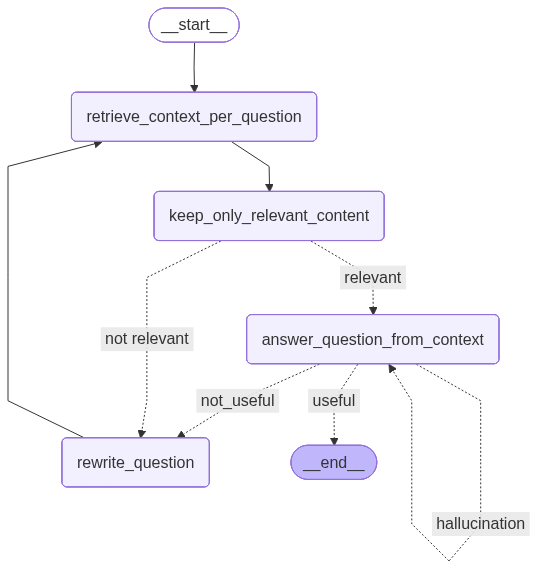

In [21]:
# -----------------------------------------------
# Qualitative Retrieval Answer Graph Construction
# -----------------------------------------------

# Define the state for the workflow graph
class QualitativeRetievalAnswerGraphState(TypedDict):
    question: str
    context: str
    answer: str

# Create the workflow graph object
qualitative_retrieval_answer_workflow = StateGraph(QualitativeRetievalAnswerGraphState)
# Node: Retrieve context for the question from vector stores
qualitative_retrieval_answer_workflow.add_node("retrieve_context_per_question", retrieve_context_per_question)
# Node: Use LLM to keep only relevant content from the retrieved context
qualitative_retrieval_answer_workflow.add_node("keep_only_relevant_content", keep_only_relevant_content)
# Node: Rewrite the question for better retrieval if needed
qualitative_retrieval_answer_workflow.add_node("rewrite_question", rewrite_question)
# Node: Answer the question from the relevant context using LLM
qualitative_retrieval_answer_workflow.add_node("answer_question_from_context", answer_question_from_context)
# -------------------------
# Build the Workflow Edges
# -------------------------
# Set the entry point of the workflow
qualitative_retrieval_answer_workflow.set_entry_point("retrieve_context_per_question")
# Edge: After retrieving context, filter to keep only relevant content
qualitative_retrieval_answer_workflow.add_edge("retrieve_context_per_question", "keep_only_relevant_content")
# Conditional Edge: After filtering, check if content is relevant
# If relevant, answer the question; if not, rewrite the question
qualitative_retrieval_answer_workflow.add_conditional_edges("keep_only_relevant_content", is_relevant_content,
    {
        "relevant": "answer_question_from_context",
        "not relevant": "rewrite_question"
    },
)
# Edge: After rewriting the question, retrieve context again
qualitative_retrieval_answer_workflow.add_edge("rewrite_question", "retrieve_context_per_question")
# Conditional Edge: After answering, grade the answer
# If hallucination, try answering again; if not useful, rewrite question; if useful, end
qualitative_retrieval_answer_workflow.add_conditional_edges("answer_question_from_context", grade_generation_v_documents_and_question,
    {
        "hallucination": "answer_question_from_context",
        "not_useful": "rewrite_question",
        "useful": END
    },
)

# Compile the workflow graph into an executable app
qualitative_retrieval_answer_retrival_app = qualitative_retrieval_answer_workflow.compile()
# Display the workflow graph as a Mermaid diagram
display(
    Image(
        qualitative_retrieval_answer_retrival_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [26]:
query = "Who is Harry Potter ?"
state = {
    "messages": [HumanMessage(content=query)],
    "question": query,
}
final_state = qualitative_retrieval_answer_retrival_app.invoke(state)
final_state

Retrieving relevant chunks...
Retrieving relevant chapter summaries...
Retrieving relevant book quotes...
Keeping only the relevant content...
'--------------------'


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=KeepRelevantContent(relev...tchcraft and Wizardry."), input_type=KeepRelevantContent])
  return self.__pydantic_serializer__.to_python(


Determining if the document is relevant...
The document is relevant.
Answering the question from the retrieved context...


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=QuestionAnswerFromContext...il Hagrid revealed it."), input_type=QuestionAnswerFromContext])
  return self.__pydantic_serializer__.to_python(


answer before checking hallucination: Harry Potter is a famous wizard in the wizarding world, known as 'the boy who lived' because he survived an attack by the dark wizard Lord Voldemort as a baby. He is the son of Lily and James Potter, both of whom were killed by Voldemort. Harry is eleven years old, has a lightning-bolt-shaped scar on his forehead, and has just discovered that he has been accepted to Hogwarts School of Witchcraft and Wizardry. He was raised by his aunt and uncle, the Dursleys, who kept his true identity hidden from him until Hagrid revealed it.
Checking if the answer is grounded in the facts...


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=IsGroundedOnFacts(grounded_on_facts=True), input_type=IsGroundedOnFacts])
  return self.__pydantic_serializer__.to_python(


The answer is grounded in the facts.
Determining if the question is fully answered...
The question can be fully answered.


{'question': 'Who is Harry Potter ?',
 'context': 'happen. Harry Potter rolled over inside his blankets without waking up. One\nsmall hand closed on the letter beside him and he slept on, not knowing he was\nspecial, not knowing he was famous, not knowing he would be woken in a few\nhours’ time by Mrs. Dursley’s scream as she opened the front door to put out the\nmilk bottles, nor that he would spend the next few weeks being prodded and\npinched by his cousin Dudley....He couldn’t know that at this very moment,\npeople meeting in secret all over the country were holding up their glasses and\nsaying in hushed voices: “To Harry Potter — the boy who lived!” left fer him? I was there! I saw Dumbledore leave it, Dursley! An’ you’ve kept it\nfrom him all these years?”\n      “Kept what from me?” said Harry eagerly.\n      “STOP! I FORBID YOU!” yelled Uncle Vernon in panic.\n      Aunt Petunia gave a gasp of horror.\n      “Ah, go boil yer heads, both of yeh,” said Hagrid. “Harry — yer a\nwiz

In [27]:
# --- Function: Check if Distilled Content is Grounded in the Original Context ---
# Output schema for the LLM's response
class IsDistilledContentGroundedOnContent(BaseModel):
    grounded: bool = Field(
        description="Whether the distilled content is grounded on the original context."
    )
    explanation: str = Field(
        description="An explanation of why the distilled content is or is not grounded on the original context."
    )

# JSON parser for the output schema
is_distilled_content_grounded_on_content_json_parser = JsonOutputParser(
    pydantic_object=IsDistilledContentGroundedOnContent
)

# Create the prompt object for the LLM
is_distilled_content_grounded_on_content_prompt = PromptTemplate(
    template=is_distilled_content_grounded_on_content_prompt_template,
    input_variables=["distilled_content", "original_context"],
    partial_variables={
        "format_instructions": is_distilled_content_grounded_on_content_json_parser.get_format_instructions()
    },
)

# Compose the chain: prompt -> LLM -> output parser
is_distilled_content_grounded_on_content_chain = (
    is_distilled_content_grounded_on_content_prompt
    | llm
    | is_distilled_content_grounded_on_content_json_parser
)

def is_distilled_content_grounded_on_content(state):
    """
    Determines if the distilled content is grounded on the original context.

    Args:
        state (dict): A dictionary containing:
            - "relevant_context": The distilled content.
            - "context": The original context.

    Returns:
        str: "grounded on the original context" if grounded, otherwise "not grounded on the original context".
    """
    pprint("--------------------")
    print("Determining if the distilled content is grounded on the original context...")

    distilled_content = state["relevant_context"]
    original_context = state["context"]

    input_data = {
        "distilled_content": distilled_content,
        "original_context": original_context
    }

    # Invoke the LLM chain to check grounding
    output = is_distilled_content_grounded_on_content_chain.invoke(input_data)
    grounded = output["grounded"]

    if grounded:
        print("The distilled content is grounded on the original context.")
        return "grounded on the original context"
    else:
        print("The distilled content is not grounded on the original context.")
        return "not grounded on the original context"

In [35]:
# -----------------------------------------------------------
# Retrieval Functions for Different Context Types
# -----------------------------------------------------------

def retrieve_chunks_context_per_question(state):
    """
    Retrieves relevant context for a given question from the book chunks.

    Args:
        state (dict): A dictionary containing the question to answer, with key "question".

    Returns:
        dict: A dictionary with keys:
            - "context": Aggregated context string from relevant book chunks.
            - "question": The original question.
    """
    print("Retrieving relevant chunks...")
    question = state["question"]
    # Retrieve relevant book chunks using the retriever
    docs = chunks_query_retriever.invoke(question)
    # Concatenate the content of the retrieved documents
    context = " ".join(doc.page_content for doc in docs)
    context = escape_quotes(context)
    return {"context": context, "question": question}

def retrieve_summaries_context_per_question(state):
    """
    Retrieves relevant context for a given question from chapter summaries.

    Args:
        state (dict): A dictionary containing the question to answer, with key "question".

    Returns:
        dict: A dictionary with keys:
            - "context": Aggregated context string from relevant chapter summaries.
            - "question": The original question.
    """
    print("Retrieving relevant chapter summaries...")
    question = state["question"]
    # Retrieve relevant chapter summaries using the retriever
    docs_summaries = chapter_summaries_query_retriever.invoke(question)
    # Concatenate the content of the retrieved summaries, including chapter citation
    context_summaries = " ".join(
        f"{doc.page_content} (Chapter {doc.metadata['chapter']})" for doc in docs_summaries
    )
    context_summaries = escape_quotes(context_summaries)
    return {"context": context_summaries, "question": question}

def retrieve_book_quotes_context_per_question(state):
    """
    Retrieves relevant context for a given question from book quotes.

    Args:
        state (dict): A dictionary containing the question to answer, with key "question".

    Returns:
        dict: A dictionary with keys:
            - "context": Aggregated context string from relevant book quotes.
            - "question": The original question.
    """
    question = state["question"]
    print("Retrieving relevant book quotes...")
    # Retrieve relevant book quotes using the retriever
    docs_book_quotes = book_quotes_query_retriever.invoke(question)
    # Concatenate the content of the retrieved quotes
    book_quotes = " ".join(doc.page_content for doc in docs_book_quotes)
    book_quotes_context = escape_quotes(book_quotes)
    return {"context": book_quotes_context, "question": question}

In [36]:
class QualitativeRetrievalGraphState(TypedDict):
    """
    Represents the state of the qualitative retrieval graph.

    Attributes:
        question (str): The input question to be answered.
        context (str): The context retrieved from the source (e.g., book chunks, summaries, or quotes).
        relevant_context (str): The distilled or filtered context that is most relevant to the question.
    """
    question: str
    context: str
    relevant_context: str

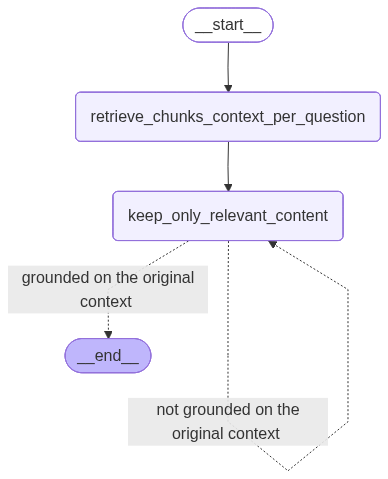

In [37]:
# -----------------------------------------------------------
# Qualitative Chunks Retrieval Workflow Graph Construction
# -----------------------------------------------------------
# 1. Create the workflow graph object with the appropriate state type
qualitative_chunks_retrieval_workflow = StateGraph(QualitativeRetrievalGraphState)
# 2. Define and add nodes to the graph
# Node: Retrieve relevant context from book chunks for the question
qualitative_chunks_retrieval_workflow.add_node(
    "retrieve_chunks_context_per_question",
    retrieve_chunks_context_per_question
)
# Node: Use LLM to keep only the relevant content from the retrieved context
qualitative_chunks_retrieval_workflow.add_node(
    "keep_only_relevant_content",
    keep_only_relevant_content
)

# 3. Set the entry point of the workflow
qualitative_chunks_retrieval_workflow.set_entry_point("retrieve_chunks_context_per_question")

# 4. Add edges to define the workflow
# After retrieving context, filter to keep only relevant content
qualitative_chunks_retrieval_workflow.add_edge(
    "retrieve_chunks_context_per_question",
    "keep_only_relevant_content"
)

# Conditional edge: After filtering, check if distilled content is grounded in the original context
# If grounded, end; if not, repeat filtering
qualitative_chunks_retrieval_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_distilled_content_grounded_on_content,
    {
        "grounded on the original context": END,
        "not grounded on the original context": "keep_only_relevant_content"
    },
)

# 5. Compile the workflow graph into an executable app
qualitative_chunks_retrieval_workflow_app = qualitative_chunks_retrieval_workflow.compile()

# 6. Display the workflow graph as a Mermaid diagram
display(
    Image(
        qualitative_chunks_retrieval_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

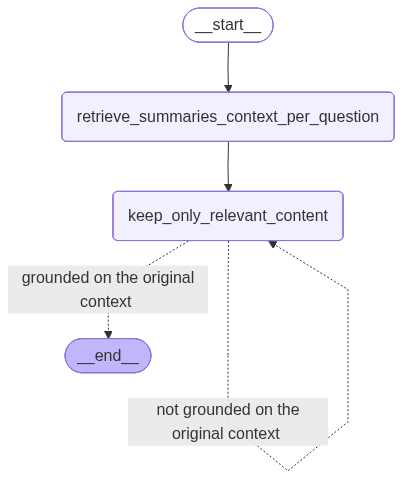

In [38]:
# -----------------------------------------------------------
# Qualitative Summaries Retrieval Workflow Graph Construction
# -----------------------------------------------------------

# 1. Create the workflow graph object with the appropriate state type
qualitative_summaries_retrieval_workflow = StateGraph(QualitativeRetrievalGraphState)

# 2. Define and add nodes to the graph
# Node: Retrieve relevant context from chapter summaries for the question
qualitative_summaries_retrieval_workflow.add_node(
    "retrieve_summaries_context_per_question",
    retrieve_summaries_context_per_question
)
# Node: Use LLM to keep only the relevant content from the retrieved context
qualitative_summaries_retrieval_workflow.add_node(
    "keep_only_relevant_content",
    keep_only_relevant_content
)

# 3. Set the entry point of the workflow
qualitative_summaries_retrieval_workflow.set_entry_point("retrieve_summaries_context_per_question")

# 4. Add edges to define the workflow
# After retrieving context, filter to keep only relevant content
qualitative_summaries_retrieval_workflow.add_edge(
    "retrieve_summaries_context_per_question",
    "keep_only_relevant_content"
)

# Conditional edge: After filtering, check if distilled content is grounded in the original context
# If grounded, end; if not, repeat filtering
qualitative_summaries_retrieval_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_distilled_content_grounded_on_content,
    {
        "grounded on the original context": END,
        "not grounded on the original context": "keep_only_relevant_content"
    },
)

# 5. Compile the workflow graph into an executable app
qualitative_summaries_retrieval_workflow_app = qualitative_summaries_retrieval_workflow.compile()

# 6. Display the workflow graph as a Mermaid diagram
display(
    Image(
        qualitative_summaries_retrieval_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

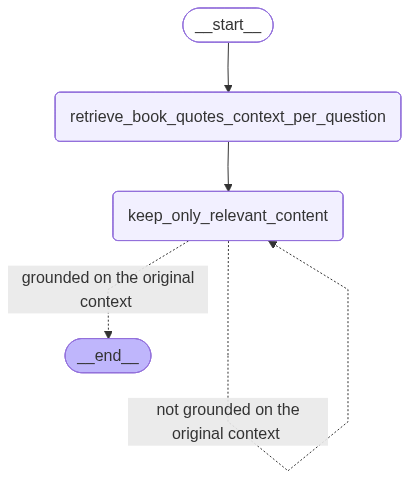

In [39]:
# -----------------------------------------------------------
# Qualitative Book Quotes Retrieval Workflow Graph Construction
# -----------------------------------------------------------

# 1. Create the workflow graph object with the appropriate state type
qualitative_book_quotes_retrieval_workflow = StateGraph(QualitativeRetrievalGraphState)

# 2. Define and add nodes to the graph
# Node: Retrieve relevant context from book quotes for the question
qualitative_book_quotes_retrieval_workflow.add_node(
    "retrieve_book_quotes_context_per_question",
    retrieve_book_quotes_context_per_question
)
# Node: Use LLM to keep only the relevant content from the retrieved context
qualitative_book_quotes_retrieval_workflow.add_node(
    "keep_only_relevant_content",
    keep_only_relevant_content
)

# 3. Set the entry point of the workflow
qualitative_book_quotes_retrieval_workflow.set_entry_point("retrieve_book_quotes_context_per_question")

# 4. Add edges to define the workflow
# After retrieving context, filter to keep only relevant content
qualitative_book_quotes_retrieval_workflow.add_edge(
    "retrieve_book_quotes_context_per_question",
    "keep_only_relevant_content"
)

# Conditional edge: After filtering, check if distilled content is grounded in the original context
# If grounded, end; if not, repeat filtering
qualitative_book_quotes_retrieval_workflow.add_conditional_edges(
    "keep_only_relevant_content",
    is_distilled_content_grounded_on_content,
    {
        "grounded on the original context": END,
        "not grounded on the original context": "keep_only_relevant_content"
    },
)

# 5. Compile the workflow graph into an executable app
qualitative_book_quotes_retrieval_workflow_app = qualitative_book_quotes_retrieval_workflow.compile()

# 6. Display the workflow graph as a Mermaid diagram
display(
    Image(
        qualitative_book_quotes_retrieval_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [42]:
init_state = {
    "question": "What is the magic stone ?"  # The question to answer
}

In [43]:
# Stream the outputs from the qualitative_chunks_retrieval_workflow_app
# for the given initial state (init_state contains the question to answer).
for output in qualitative_chunks_retrieval_workflow_app.stream(init_state):
    for _, value in output.items():
        pass  # The value variable will hold the latest state after each node execution
    pprint("--------------------")  # Print a separator for clarity between steps

# After the workflow completes, print the final relevant context extracted
print(f'relevant context: {value["relevant_context"]}')

Retrieving relevant chunks...
'--------------------'
Keeping only the relevant content...
'--------------------'


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=KeepRelevantContent(relev...’d gotten the Stone.'), input_type=KeepRelevantContent])
  return self.__pydantic_serializer__.to_python(


'--------------------'
Determining if the distilled content is grounded on the original context...
The distilled content is grounded on the original context.
'--------------------'
relevant context: a legendary substance with astonishing powers. The stone will transform any metal into pure gold. It also produces the Elixir of Life, which will make the drinker immortal. There have been many reports of the Sorcerer’s Stone over the centuries, but the only Stone currently in existence belongs to Mr. Nicolas Flamel, the noted alchemist and opera lover. Mr. Flamel, who celebrated his six hundred and sixty-fifth birthday last year, enjoys a quiet life in Devon with his wife, Perenelle (six hundred and fifty-eight). ... “A stone that makes gold and stops you from ever dying!” ... “Nicolas Flamel,” she whispered dramatically, “is the only known maker of the Sorcerer’s Stone!” ... The ancient study of alchemy is concerned with making the Sorcerer’s Stone ... “So we were right, it is the Sorcere

In [44]:
for output in qualitative_summaries_retrieval_workflow_app.stream(init_state):
    # Iterate through the output items (node name, value)
    for _, value in output.items():
        pass  # The value variable will hold the latest state after each node execution
    pprint("--------------------")  # Print a separator for clarity between steps

# After the workflow completes, print the final relevant context extracted
print(f'relevant context: {value["relevant_context"]}')

Retrieving relevant chapter summaries...
'--------------------'
Keeping only the relevant content...
'--------------------'


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=KeepRelevantContent(relev...y and infinite wealth."), input_type=KeepRelevantContent])
  return self.__pydantic_serializer__.to_python(


'--------------------'
Determining if the distilled content is grounded on the original context...
The distilled content is grounded on the original context.
'--------------------'
relevant context: The Sorcerer\'s Stone is a legendary alchemical substance that can turn any metal into gold and produce the Elixir of Life, granting immortality. The only existing Stone belongs to Nicolas Flamel, who is 665 years old and lives in Devon with his wife. The three-headed dog, Fluffy, is guarding Flamel\'s Sorcerer\'s Stone. Flamel asked his friend Dumbledore to keep it safe at Hogwarts after someone tried to steal it from Gringotts. The Stone grants immortality and infinite wealth.


In [45]:
for output in qualitative_book_quotes_retrieval_workflow_app.stream(init_state):
    # Iterate through the output items (node name, value)
    for _, value in output.items():
        pass  # The value variable will hold the latest state after each node execution
    pprint("--------------------")  # Print a separator for clarity between steps

# After the workflow completes, print the final relevant context extracted
print(f'relevant context: {value["relevant_context"]}')

Retrieving relevant book quotes...
'--------------------'
Keeping only the relevant content...
'--------------------'


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=KeepRelevantContent(relev... the Elixir of Life!"), input_type=KeepRelevantContent])
  return self.__pydantic_serializer__.to_python(


'--------------------'
Determining if the distilled content is grounded on the original context...
The distilled content is grounded on the original context.
'--------------------'
relevant context: The Sorcerer\'s Stone! Of course — the Elixir of Life!


In [46]:
def is_answer_grounded_on_context(state):
    """
    Determines if the answer to the question is grounded in the provided context (i.e., not a hallucination).

    Args:
        state (dict): A dictionary containing:
            - "context": The context used to answer the question.
            - "answer": The generated answer to the question.

    Returns:
        str: "hallucination" if the answer is not grounded in the context, 
             "grounded on context" if the answer is supported by the context.
    """
    print("Checking if the answer is grounded in the facts...")

    # Extract context and answer from the state
    context = state["context"]
    answer = state["answer"]

    # Use the LLM chain to check if the answer is grounded in the context
    result = is_grounded_on_facts_chain.invoke({"context": context, "answer": answer})
    grounded_on_facts = result.grounded_on_facts

    # Return the result based on grounding
    if not grounded_on_facts:
        print("The answer is hallucination.")
        return "hallucination"
    else:
        print("The answer is grounded in the facts.")
        return "grounded on context"

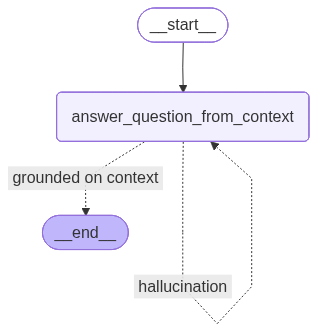

In [47]:
# -----------------------------------------------
# Qualitative Answer Workflow Graph Construction
# -----------------------------------------------

# Define the state for the answer workflow graph
class QualitativeAnswerGraphState(TypedDict):
    """
    Represents the state of the qualitative answer graph.

    Attributes:
        question (str): The input question to be answered.
        context (str): The context used to answer the question.
        answer (str): The generated answer to the question.
    """
    question: str
    context: str
    answer: str

# Create the workflow graph object
qualitative_answer_workflow = StateGraph(QualitativeAnswerGraphState)

# -------------------------
# Define and Add Graph Nodes
# -------------------------

# Node: Answer the question from the provided context using LLM
qualitative_answer_workflow.add_node(
    "answer_question_from_context",
    answer_question_from_context
)
# Set the entry point of the workflow
qualitative_answer_workflow.set_entry_point("answer_question_from_context")

# Conditional Edge: After answering, check if the answer is grounded in the context
# If hallucination, try answering again; if grounded, end
qualitative_answer_workflow.add_conditional_edges("answer_question_from_context", is_answer_grounded_on_context,
    {
        "hallucination": "answer_question_from_context",
        "grounded on context": END
    }
)
# Compile the workflow graph into an executable app
qualitative_answer_workflow_app = qualitative_answer_workflow.compile()

# Display the workflow graph as a Mermaid diagram
display(
    Image(
        qualitative_answer_workflow_app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [48]:
# -----------------------------------------------
# Test the qualitative answer workflow graph
# -----------------------------------------------
question = "who is harry?"  # The question to answer
context = "Harry Potter is a cat."  # The context to answer the question from
# Initialize the state for the workflow
init_state = {
    "question": question,
    "context": context
}

for output in qualitative_answer_workflow_app.stream(init_state):
    # Iterate through the output items (node name, value)
    for _, value in output.items():
        pass  # The value variable holds the latest state after each node execution
    pprint("--------------------")  # Print a separator for clarity between steps

# After the workflow completes, print the final answer generated by the workflow
print(f'answer: {value["answer"]}')

Answering the question from the retrieved context...


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=QuestionAnswerFromContext...Harry Potter is a cat.'), input_type=QuestionAnswerFromContext])
  return self.__pydantic_serializer__.to_python(


answer before checking hallucination: Harry Potter is a cat.
Checking if the answer is grounded in the facts...
The answer is grounded in the facts.
'--------------------'
answer: Harry Potter is a cat.


In [49]:
from typing import TypedDict, List, Dict

class PlanExecute(TypedDict):
    """
    Represents the state at each step of the plan execution pipeline.

    Attributes:
        curr_state (str): The current state or status of the execution.
        question (str): The original user question.
        anonymized_question (str): The anonymized version of the question (entities replaced with variables).
        query_to_retrieve_or_answer (str): The query to be used for retrieval or answering.
        plan (List[str]): The current plan as a list of steps to execute.
        past_steps (List[str]): List of steps that have already been executed.
        mapping (dict): Mapping of anonymized variables to original named entities.
        curr_context (str): The current context used for answering or retrieval.
        aggregated_context (str): The accumulated context from previous steps.
        tool (str): The tool or method used for the current step (e.g., retrieval, answer).
        response (str): The response or output generated at this step.
    """
    curr_state: str
    question: str
    anonymized_question: str
    query_to_retrieve_or_answer: str
    plan: List[str]
    past_steps: List[str]
    mapping: Dict[str, str]
    curr_context: str
    aggregated_context: str
    tool: str
    response: str

In [51]:
# -----------------------------------------------
# Planning Component for Multi-Step Question Answering
# -----------------------------------------------
# Define the output schema for the plan
class Plan(BaseModel):
    """
    Represents a step-by-step plan to answer a given question.
    Attributes:
        steps (List[str]): Ordered list of steps to follow.
    """
    steps: List[str] = Field(
        description="different steps to follow, should be in sorted order"
    )

planner_prompt = PromptTemplate(
    template=planner_prompt,
    input_variables=["question"],
)

# Compose the planning chain: prompt -> LLM -> structured output
planner = planner_prompt | llm.with_structured_output(Plan)

In [52]:
# -----------------------------------------------------------
# Chain to Refine a Plan into Executable Steps for Retrieval/Answering
# -----------------------------------------------------------
# Create a PromptTemplate for the LLM
break_down_plan_prompt = PromptTemplate(
    template=break_down_plan_prompt_template,
    input_variables=["plan"],
)

# Compose the chain: prompt -> LLM -> structured output (Plan)
break_down_plan_chain = break_down_plan_prompt | llm.with_structured_output(Plan)

In [53]:
# -----------------------------------------------------------
# Example: How to Use the Planner and Refine the Plan
# -----------------------------------------------------------
# 1. Define the question to answer
question = {"question": "how did the main character beat the villain?"}
# 2. Generate a step-by-step plan to answer the question using the planner chain
my_plan = planner.invoke(question)
print("Initial Plan:")
print(my_plan)
# 3. Refine the plan so that each step is executable by a retrieval or answer operation
refined_plan = break_down_plan_chain.invoke(my_plan.steps)
print("\nRefined Plan:")
print(refined_plan)

/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(steps=['Identify the... as the final answer.']), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


Initial Plan:
steps=['Identify the main character and the villain from the query.', 'Locate the specific story or work (e.g., book, movie, game) that contains this conflict.', 'Find the scene or chapter where the main character defeats the villain.', 'Read or watch that scene carefully, noting the specific actions, strategies, or weaknesses used.', 'Summarize the method of victory in a clear, step-by-step sequence.', 'Output that summary as the final answer.']

Refined Plan:
steps=['Retrieve from the vector store of book chunks the name of the main character and the villain based on the query.', 'Retrieve from the vector store of chapter summaries the specific story or work (e.g., book, movie, game) that contains the conflict between the main character and the villain.', 'Retrieve from the vector store of chapter summaries the scene or chapter where the main character defeats the villain.', 'Retrieve from the vector store of book quotes the specific actions, strategies, or weaknesses u

/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(steps=['Retrieve fro... defeat the villain?'"]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


In [54]:
# -----------------------------------------------------------
# Replanner: Update Plan Based on Progress and Aggregated Context
# -----------------------------------------------------------

# Define a Pydantic model for the possible results of the replanning action
class ActPossibleResults(BaseModel):
    """
    Represents the possible results of the replanning action.

    Attributes:
        plan (Plan): The updated plan to follow in the future.
        explanation (str): Explanation of the action taken or the reasoning behind the plan update.
    """
    plan: Plan = Field(description="Plan to follow in future.")
    explanation: str = Field(description="Explanation of the action.")

# Create a JSON output parser for the ActPossibleResults schema
act_possible_results_parser = JsonOutputParser(pydantic_object=ActPossibleResults)
# Create a PromptTemplate object for the replanner
replanner_prompt = PromptTemplate(
    template=replanner_prompt_template,
    input_variables=["question", "plan", "past_steps", "aggregated_context"],
    partial_variables={"format_instructions": act_possible_results_parser.get_format_instructions()},
)

# Compose the replanner chain: prompt -> LLM -> output parser
replanner = replanner_prompt | llm | act_possible_results_parser

In [55]:
# -----------------------------------------------------------
# Task Handler: Decide Which Tool to Use for Each Task
# -----------------------------------------------------------
# Output schema for the task handler
class TaskHandlerOutput(BaseModel):
    """
    Output schema for the task handler.
    - query: The query to be either retrieved from the vector store, or the question that should be answered from context.
    - curr_context: The context to be based on in order to answer the query.
    - tool: The tool to be used; should be one of 'retrieve_chunks', 'retrieve_summaries', 'retrieve_quotes', or 'answer_from_context'.
    """
    query: str = Field(description="The query to be either retrieved from the vector store, or the question that should be answered from context.")
    curr_context: str = Field(description="The context to be based on in order to answer the query.")
     tool: Literal[
            "retrieve_chunks", "retrieve_summaries", "retrieve_quotes", "answer_from_context"
        ] = Field(
            description="The tool to be used should be either retrieve_chunks, retrieve_summaries, retrieve_quotes, or answer_from_context."
        )
# Create the prompt object for the task handler
task_handler_prompt = PromptTemplate(
    template=tasks_handler_prompt_template,
    input_variables=["curr_task", "aggregated_context", "last_tool", "past_steps", "question"],
)


# Compose the task handler chain: prompt -> LLM -> structured output
task_handler_chain = task_handler_prompt | llm.with_structured_output(TaskHandlerOutput)

In [56]:
# -----------------------------------------------------------
# Anonymize Question Chain: Replace Named Entities with Variables
# -----------------------------------------------------------

# Define a Pydantic model for the anonymized question output
class AnonymizeQuestion(BaseModel):
  """
  Output schema for the anonymized question.
  Attributes:
    anonymized_question (str): The question with named entities replaced by variables.
    mapping (dict): Mapping of variables to original named entities.
    explanation (str): Explanation of the anonymization process.
  """
  anonymized_question: str = Field(description="Anonymized question.")
  mapping: dict = Field(description="Mapping of original name entities to variables.")
  explanation: str = Field(description="Explanation of the action.")

# Create a JSON output parser for the AnonymizeQuestion schema
anonymize_question_parser = JsonOutputParser(pydantic_object=AnonymizeQuestion)
# Create the PromptTemplate object for the anonymization task
anonymize_question_prompt = PromptTemplate(
  template=anonymize_question_prompt_template,
  input_variables=["question"],
  partial_variables={"format_instructions": anonymize_question_parser.get_format_instructions()},
)

# Compose the anonymization chain: prompt -> LLM -> output parser
anonymize_question_chain = (
  anonymize_question_prompt
  | llm
  | anonymize_question_parser
)

In [58]:
# -----------------------------------------------------------
# De-Anonymize Plan Chain: Replace Variables in Plan with Mapped Words
# -----------------------------------------------------------


class DeAnonymizePlan(BaseModel):
    """
    Output schema for the de-anonymized plan.
    Attributes:
        plan (List): Plan to follow in future, with all variables replaced by the mapped words.
    """
    plan: List = Field(
        description="Plan to follow in future. with all the variables replaced with the mapped words."
    )
# Create the PromptTemplate object for the de-anonymization task
de_anonymize_plan_prompt = PromptTemplate(
    template=de_anonymize_plan_prompt_template,
    input_variables=["plan", "mapping"],
)

# Compose the de-anonymization chain: prompt -> LLM -> structured output
de_anonymize_plan_chain = (
    de_anonymize_plan_prompt
    | llm.with_structured_output(DeAnonymizePlan)
)

In [59]:
# -----------------------------------------------------------
# Example: Anonymize, Plan, and De-anonymize a Question
# -----------------------------------------------------------

# 1. Define the question to answer
state1 = {
    'question': "how did the harry beat quirrell? \n"
}
print(f'question: {state1["question"]}')

# 2. Anonymize the question (replace named entities with variables)
anonymized_question_output = anonymize_question_chain.invoke(state1)
anonymized_question = anonymized_question_output["anonymized_question"]  # The anonymized question
mapping = anonymized_question_output["mapping"]  # Mapping of variables to original entities

print(f'anonymized_query: {anonymized_question} \n')
print(f'mapping: {mapping} \n')

# 3. Generate a step-by-step plan for the anonymized question
plan = planner.invoke({"question": anonymized_question})
print(text_wrap(f'plan: {plan.steps}'))
print("")

# 4. De-anonymize the plan (replace variables back with original entities)
deanonymized_plan = de_anonymize_plan_chain.invoke({
    "plan": plan.steps,
    "mapping": mapping
})
print(text_wrap(f'deanonymized_plan: {deanonymized_plan.plan}'))

question: how did the harry beat quirrell? 

anonymized_query: how did the X beat Y? 

mapping: {'X': 'harry', 'Y': 'quirrell'} 



/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(steps=["Identify the... 'how did X beat Y?'."]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


plan: ["Identify the specific entities X and Y from the query (e.g., 'the 1990s Chicago Bulls beat the Utah Jazz').",
'Determine the context of the competition (e.g., sports match, game, election, business rivalry).', 'Search for reliable
sources (e.g., official records, news articles, historical data) that describe the event where X defeated Y.', 'Extract
the key reasons or methods from those sources that explain how X achieved victory over Y (e.g., superior strategy, key
player performance, decisive move).', "Summarize those reasons into a concise answer that directly responds to 'how did
X beat Y?'."]

deanonymized_plan: ["Identify the specific entities harry and quirrell from the query (e.g., 'the 1990s Chicago Bulls
beat the Utah Jazz').", 'Determine the context of the competition (e.g., sports match, game, election, business
rivalry).', 'Search for reliable sources (e.g., official records, news articles, historical data) that describe the
event where harry defeated quirrell.', 'E

/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DeAnonymizePlan(plan=["Id...arry beat quirrell?'."]), input_type=DeAnonymizePlan])
  return self.__pydantic_serializer__.to_python(


In [60]:
# -----------------------------------------------------------
# LLM Chain: Check if a Question Can Be Fully Answered from Context
# -----------------------------------------------------------

# Define the output schema for the LLM's response
class CanBeAnsweredAlready(BaseModel):
    """
    Output schema for checking if the question can be fully answered from the given context.
    Attributes:
        can_be_answered (bool): Whether the question can be fully answered or not based on the given context.
    """
    can_be_answered: bool = Field(
        description="Whether the question can be fully answered or not based on the given context."
    )
# Create the PromptTemplate object
can_be_answered_already_prompt = PromptTemplate(
    template=can_be_answered_already_prompt_template,
    input_variables=["question", "context"],
)

# Compose the chain: prompt -> LLM -> structured output
can_be_answered_already_chain = (
    can_be_answered_already_prompt
    | llm.with_structured_output(CanBeAnsweredAlready)
)

In [80]:
def run_task_handler_chain(state: PlanExecute):
    """
    Run the task handler chain to decide which tool to use to execute the task.

    Args:
        state: The current state of the plan execution.

    Returns:
        The updated state of the plan execution.
    """
    state["curr_state"] = "task_handler"
    print("the current plan is:")
    print(state["plan"])
    pprint("--------------------")

    # Initialize past_steps if not present
    if not state.get("past_steps"):
        state["past_steps"] = []
    # Get the current task from the plan
    curr_task = state["plan"][0]

    # Prepare inputs for the task handler chain
    inputs = {
        "curr_task": curr_task,
        "aggregated_context": state.get("aggregated_context", ""),
        "last_tool": state.get("tool", ""),
        "past_steps": state["past_steps"],
        "question": state["question"],
    }

    # Invoke the task handler chain
    output = task_handler_chain.invoke(inputs)

    # Update state with the completed task
    state["past_steps"].append(curr_task)
    state["plan"].pop(0)

    # Decide which tool to use based on output
    if output.tool == "retrieve_chunks":
        state["query_to_retrieve_or_answer"] = output.query
        state["tool"] = "retrieve_chunks"
    elif output.tool == "retrieve_summaries":
        state["query_to_retrieve_or_answer"] = output.query
        state["tool"] = "retrieve_summaries"
    elif output.tool == "retrieve_quotes":
        state["query_to_retrieve_or_answer"] = output.query
        state["tool"] = "retrieve_quotes"
    elif output.tool == "answer_from_context":
        state["query_to_retrieve_or_answer"] = output.query
        state["curr_context"] = output.curr_context
        state["tool"] = "answer"
    else:
        raise ValueError(
            "Invalid tool was outputted by task handler. Must be one of "
            f"'retrieve_chunks', 'retrieve_summaries', 'retrieve_quotes', or 'answer_from_context'. "
            f"Got: {output.tool!r}"
        )
    return state


def retrieve_or_answer(state: PlanExecute):
    """
    Decide whether to retrieve or answer the question based on the current state.

    Args:
        state: The current state of the plan execution.

    Returns:
        String indicating the chosen tool.
    """
    state["curr_state"] = "decide_tool"
    print("deciding whether to retrieve or answer")
    if state["tool"] == "retrieve_chunks":
        return "chosen_tool_is_retrieve_chunks"
    elif state["tool"] == "retrieve_summaries":
        return "chosen_tool_is_retrieve_summaries"
    elif state["tool"] == "retrieve_quotes":
        return "chosen_tool_is_retrieve_quotes"
    elif state["tool"] == "answer":
        return "chosen_tool_is_answer"
    else:
        raise ValueError(
            "Invalid tool in state. Must be one of "
            f"'retrieve_chunks', 'retrieve_summaries', 'retrieve_quotes', or 'answer'. "
            f"Got: {state['tool']!r}"
        )


def run_qualitative_chunks_retrieval_workflow(state):
    """
    Run the qualitative chunks retrieval workflow.

    Args:
        state: The current state of the plan execution.

    Returns:
        The state with the updated aggregated context.
    """
    state["curr_state"] = "retrieve_chunks"
    print("Running the qualitative chunks retrieval workflow...")
    question = state["query_to_retrieve_or_answer"]
    inputs = {"question": question}
    # Stream outputs from the workflow app
    for output in qualitative_chunks_retrieval_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass
        pprint("--------------------")
    # Aggregate the retrieved context
    if not state.get("aggregated_context"):
        state["aggregated_context"] = ""
    state["aggregated_context"] += output["relevant_context"]
    return state


def run_qualitative_summaries_retrieval_workflow(state):
    """
    Run the qualitative summaries retrieval workflow.

    Args:
        state: The current state of the plan execution.

    Returns:
        The state with the updated aggregated context.
    """
    state["curr_state"] = "retrieve_summaries"
    print("Running the qualitative summaries retrieval workflow...")
    question = state["query_to_retrieve_or_answer"]
    inputs = {"question": question}
    for output in qualitative_summaries_retrieval_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass
        pprint("--------------------")
    if not state.get("aggregated_context"):
        state["aggregated_context"] = ""
    state["aggregated_context"] += output["relevant_context"]
    return state


def run_qualitative_book_quotes_retrieval_workflow(state):
    """
    Run the qualitative book quotes retrieval workflow.

    Args:
        state: The current state of the plan execution.

    Returns:
        The state with the updated aggregated context.
    """
    state["curr_state"] = "retrieve_book_quotes"
    print("Running the qualitative book quotes retrieval workflow...")
    question = state["query_to_retrieve_or_answer"]
    inputs = {"question": question}
    for output in qualitative_book_quotes_retrieval_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass
        pprint("--------------------")
    if not state.get("aggregated_context"):
        state["aggregated_context"] = ""
    state["aggregated_context"] += output["relevant_context"]
    return state


def run_qualtative_answer_workflow(state):
    """
    Run the qualitative answer workflow.

    Args:
        state: The current state of the plan execution.

    Returns:
        The state with the updated aggregated context.
    """
    state["curr_state"] = "answer"
    print("Running the qualitative answer workflow...")
    question = state["query_to_retrieve_or_answer"]
    context = state["curr_context"]
    inputs = {"question": question, "context": context}
    for output in qualitative_answer_workflow_app.stream(inputs):
        for _, _ in output.items():
            pass
        pprint("--------------------")
    if not state.get("aggregated_context"):
        state["aggregated_context"] = ""
    state["aggregated_context"] += output["answer"]
    return state


def run_qualtative_answer_workflow_for_final_answer(state):
    """
    Run the qualitative answer workflow for the final answer.

    Args:
        state: The current state of the plan execution.

    Returns:
        The state with the updated response.
    """
    state["curr_state"] = "get_final_answer"
    print("Running the qualitative answer workflow for final answer...")
    question = state["question"]
    context = state["aggregated_context"]
    inputs = {"question": question, "context": context}
    for output in qualitative_answer_workflow_app.stream(inputs):
        for _, value in output.items():
            pass
        pprint("--------------------")
    state["response"] = value
    return state


def anonymize_queries(state: PlanExecute):
    """
    Anonymizes the question.

    Args:
        state: The current state of the plan execution.

    Returns:
        The updated state with the anonymized question and mapping.
    """
    state["curr_state"] = "anonymize_question"
    print("Anonymizing question")
    pprint("--------------------")
    anonymized_question_output = anonymize_question_chain.invoke(state["question"])
    anonymized_question = anonymized_question_output["anonymized_question"]
    print(f"anonimized_querry: {anonymized_question}")
    pprint("--------------------")
    mapping = anonymized_question_output["mapping"]
    state["anonymized_question"] = anonymized_question
    state["mapping"] = mapping
    return state


def deanonymize_queries(state: PlanExecute):
    """
    De-anonymizes the plan.

    Args:
        state: The current state of the plan execution.

    Returns:
        The updated state with the de-anonymized plan.
    """
    state["curr_state"] = "de_anonymize_plan"
    print("De-anonymizing plan")
    pprint("--------------------")
    deanonimzed_plan = de_anonymize_plan_chain.invoke(
        {"plan": state["plan"], "mapping": state["mapping"]}
    )
    state["plan"] = deanonimzed_plan.plan
    print(f"de-anonimized_plan: {deanonimzed_plan.plan}")
    return state


def plan_step(state: PlanExecute):
    """
    Plans the next step.

    Args:
        state: The current state of the plan execution.

    Returns:
        The updated state with the plan.
    """
    state["curr_state"] = "planner"
    print("Planning step")
    pprint("--------------------")
    plan = planner.invoke({"question": state["anonymized_question"]})
    state["plan"] = plan.steps
    print(f'plan: {state["plan"]}')
    return state


def break_down_plan_step(state: PlanExecute):
    """
    Breaks down the plan steps into retrievable or answerable tasks.

    Args:
        state: The current state of the plan execution.

    Returns:
        The updated state with the refined plan.
    """
    state["curr_state"] = "break_down_plan"
    print("Breaking down plan steps into retrievable or answerable tasks")
    pprint("--------------------")
    refined_plan = break_down_plan_chain.invoke(state["plan"])
    state["plan"] = refined_plan.steps
    return state


def replan_step(state: PlanExecute):
    """
    Replans the next step.

    Args:
        state: The current state of the plan execution.

    Returns:
        The updated state with the plan.
    """
    state["curr_state"] = "replan"
    print("Replanning step")
    pprint("--------------------")
    inputs = {
        "question": state["question"],
        "plan": state["plan"],
        "past_steps": state["past_steps"],
        "aggregated_context": state["aggregated_context"],
    }
    output = replanner.invoke(inputs)
    state["plan"] = output["plan"]["steps"]
    return state


def can_be_answered(state: PlanExecute):
    """
    Determines if the question can be answered.

    Args:
        state: The current state of the plan execution.

    Returns:
        String indicating whether the original question can be answered or not.
    """
    state["curr_state"] = "can_be_answered_already"
    print("Checking if the ORIGINAL QUESTION can be answered already")
    pprint("--------------------")
    question = state["question"]
    context = state["aggregated_context"]
    inputs = {"question": question, "context": context}
    output = can_be_answered_already_chain.invoke(inputs)
    if output.can_be_answered == True:
        print("The ORIGINAL QUESTION can be fully answered already.")
        pprint("--------------------")
        print("the aggregated context is:")
        print(text_wrap(state["aggregated_context"]))
        print("--------------------")
        return "can_be_answered_already"
    else:
        print("The ORIGINAL QUESTION cannot be fully answered yet.")
        pprint("--------------------")
        return "cannot_be_answered_yet"

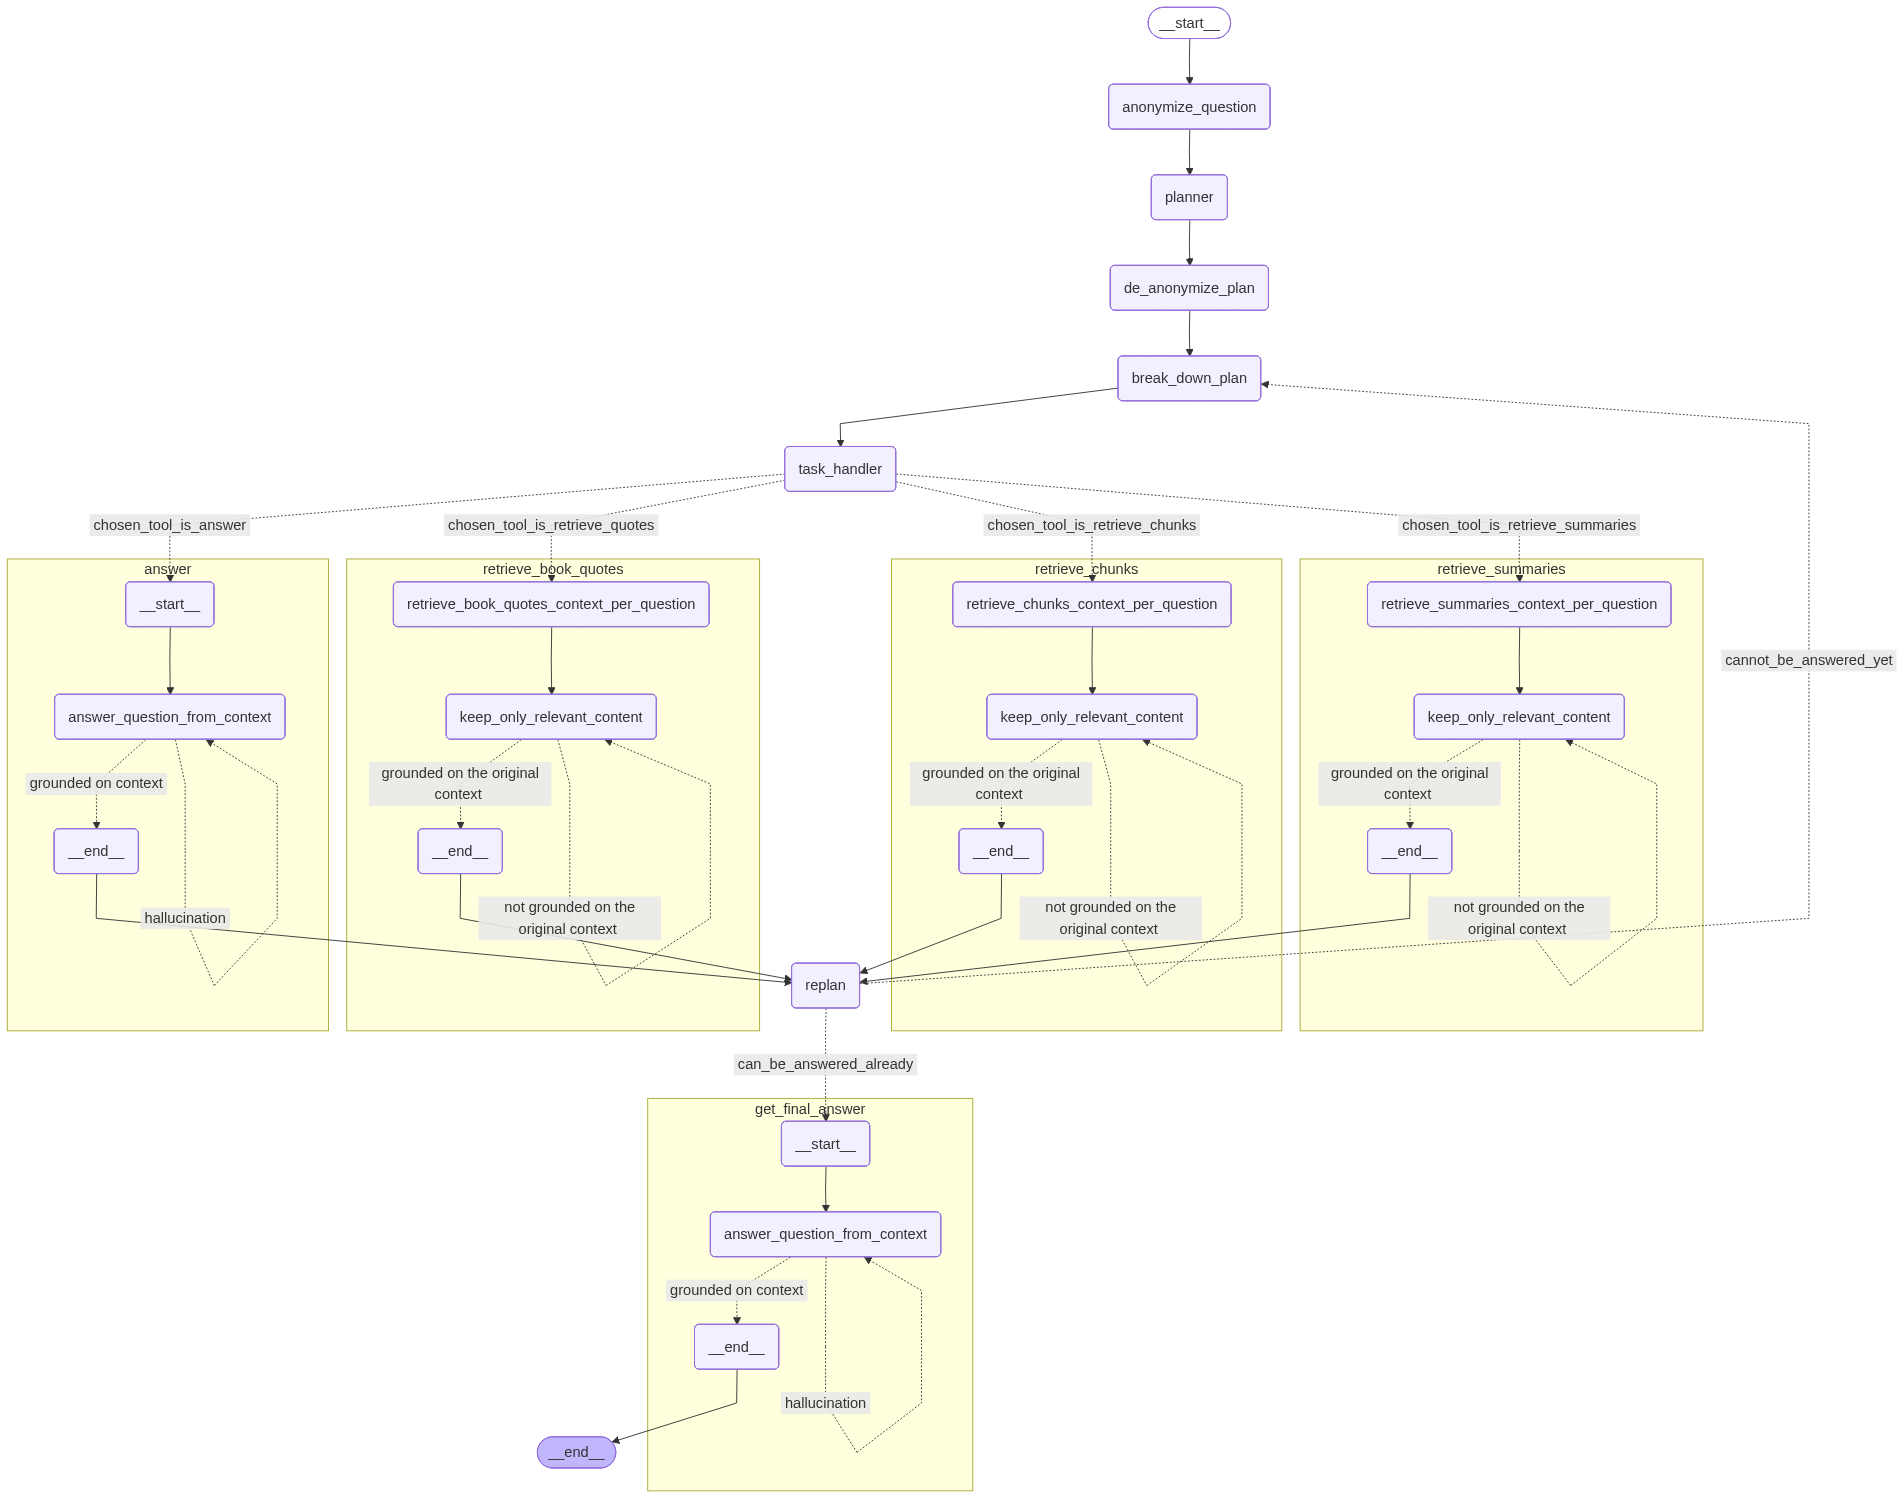

In [81]:
from langgraph.graph import StateGraph
# -----------------------------------------------------------
# Define the Plan-and-Execute Agent Workflow Graph
# -----------------------------------------------------------

# Initialize the workflow graph with the PlanExecute state
agent_workflow = StateGraph(PlanExecute)

# -------------------------
# Add Nodes (Steps/Functions)
# -------------------------

# 1. Anonymize the question (replace named entities with variables)
agent_workflow.add_node("anonymize_question", anonymize_queries)

# 2. Generate a step-by-step plan for the anonymized question
agent_workflow.add_node("planner", plan_step)

# 3. De-anonymize the plan (replace variables back with original entities)
agent_workflow.add_node("de_anonymize_plan", deanonymize_queries)

# 4. Break down the plan into retrievable/answerable tasks
agent_workflow.add_node("break_down_plan", break_down_plan_step)

# 5. Decide which tool to use for the current task
agent_workflow.add_node("task_handler", run_task_handler_chain)

# 6. Retrieve relevant book chunks
agent_workflow.add_node("retrieve_chunks", run_qualitative_chunks_retrieval_workflow)

# 7. Retrieve relevant chapter summaries
agent_workflow.add_node("retrieve_summaries", run_qualitative_summaries_retrieval_workflow)

# 8. Retrieve relevant book quotes
agent_workflow.add_node("retrieve_book_quotes", run_qualitative_book_quotes_retrieval_workflow)

# 9. Answer the question from the aggregated context
agent_workflow.add_node("answer", run_qualtative_answer_workflow)

# 10. Replan if needed (update plan based on progress/context)
agent_workflow.add_node("replan", replan_step)

# 11. Get the final answer from the aggregated context
agent_workflow.add_node("get_final_answer", run_qualtative_answer_workflow_for_final_answer)

# -------------------------
# Define Workflow Edges (Transitions)
# -------------------------

# Set the entry point of the workflow
agent_workflow.set_entry_point("anonymize_question")

# Anonymize -> Plan
agent_workflow.add_edge("anonymize_question", "planner")

# Plan -> De-anonymize
agent_workflow.add_edge("planner", "de_anonymize_plan")

# De-anonymize -> Break down plan
agent_workflow.add_edge("de_anonymize_plan", "break_down_plan")

# Break down plan -> Task handler
agent_workflow.add_edge("break_down_plan", "task_handler")

# Task handler -> (conditional) Retrieve or Answer
agent_workflow.add_conditional_edges(
    "task_handler",
    retrieve_or_answer,
    {
        "chosen_tool_is_retrieve_chunks": "retrieve_chunks",
        "chosen_tool_is_retrieve_summaries": "retrieve_summaries",
        "chosen_tool_is_retrieve_quotes": "retrieve_book_quotes",
        "chosen_tool_is_answer": "answer"
    }
)

# Retrieval/Answer nodes -> Replan
agent_workflow.add_edge("retrieve_chunks", "replan")
agent_workflow.add_edge("retrieve_summaries", "replan")
agent_workflow.add_edge("retrieve_book_quotes", "replan")
agent_workflow.add_edge("answer", "replan")

# Replan -> (conditional) Get final answer or continue
agent_workflow.add_conditional_edges(
    "replan",
    can_be_answered,
    {
        "can_be_answered_already": "get_final_answer",
        "cannot_be_answered_yet": "break_down_plan"
    }
)

# Get final answer -> End
agent_workflow.add_edge("get_final_answer", END)

# -------------------------
# Compile and Visualize the Workflow
# -------------------------

plan_and_execute_app = agent_workflow.compile()

# Display the workflow graph as a Mermaid diagram
display(Image(plan_and_execute_app.get_graph(xray=True).draw_mermaid_png()))

In [82]:
def execute_plan_and_print_steps(inputs, recursion_limit=45):
    """
    Executes the plan-and-execute agent workflow and prints each step.

    Args:
        inputs (dict): The initial input state for the plan-and-execute agent.
        recursion_limit (int): Maximum number of steps to prevent infinite loops.

    Returns:
        tuple: (response, final_state)
            response (str): The final answer or message if not found.
            final_state (dict): The final state after execution.
    """
    # Configuration for the workflow (limits recursion to avoid infinite loops)
    config = {"recursion_limit": recursion_limit}
    try:
        # Stream the outputs from the plan_and_execute_app workflow
        for plan_output in plan_and_execute_app.stream(inputs, config=config):
            # Iterate through each step's output and print the current state
            for _, agent_state_value in plan_output.items():
                pass  # agent_state_value holds the latest state after each node execution
                print(f' curr step: {agent_state_value}')
        # Extract the final response from the last state
        response = agent_state_value['response']
    except langgraph.errors.GraphRecursionError:
        # Handle the case where the recursion limit is reached
        response = "The answer wasn't found in the data."
    # Save the final state for further inspection or evaluation
    final_state = agent_state_value
    # Print the final answer in a wrapped format for readability
    print(text_wrap(f' the final answer is: {response}'))
    return response, final_state

In [83]:
# -----------------------------------------------------------
# Example: Run the Plan-and-Execute Agent for a Sample Question
# -----------------------------------------------------------

# Define the input question for the agent
input = {
    "question": "what did professor lupin teach?",
    "past_steps": []
}

# Execute the plan-and-execute workflow and print each step
final_answer, final_state = execute_plan_and_print_steps(input)

Anonymizing question
'--------------------'
anonimized_querry: what did X teach?
'--------------------'
 curr step: {'question': 'what did professor lupin teach?', 'past_steps': [], 'curr_state': 'anonymize_question', 'anonymized_question': 'what did X teach?', 'mapping': {'X': 'professor lupin'}}
Planning step
'--------------------'


/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(steps=["Identify who...ject/skill/content].'"]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


plan: ["Identify who or what 'X' refers to in the query 'what did X teach?'.", 'Determine the context or source where information about X is provided (e.g., a text, conversation, or dataset).', 'Locate the specific statement or passage that describes what X taught.', 'Extract the subject, skill, or content that X taught from that statement.', "Formulate the answer as a complete sentence: 'X taught [extracted subject/skill/content].'"]
 curr step: {'curr_state': 'planner', 'question': 'what did professor lupin teach?', 'anonymized_question': 'what did X teach?', 'past_steps': [], 'mapping': {'X': 'professor lupin'}, 'plan': ["Identify who or what 'X' refers to in the query 'what did X teach?'.", 'Determine the context or source where information about X is provided (e.g., a text, conversation, or dataset).', 'Locate the specific statement or passage that describes what X taught.', 'Extract the subject, skill, or content that X taught from that statement.', "Formulate the answer as a com

/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DeAnonymizePlan(plan=["Id...ject/skill/content].'"]), input_type=DeAnonymizePlan])
  return self.__pydantic_serializer__.to_python(


de-anonimized_plan: ["Identify who or what 'professor lupin' refers to in the query 'what did professor lupin teach?'.", 'Determine the context or source where information about professor lupin is provided (e.g., a text, conversation, or dataset).', 'Locate the specific statement or passage that describes what professor lupin taught.', 'Extract the subject, skill, or content that professor lupin taught from that statement.', "Formulate the answer as a complete sentence: 'professor lupin taught [extracted subject/skill/content].'"]
 curr step: {'curr_state': 'de_anonymize_plan', 'question': 'what did professor lupin teach?', 'anonymized_question': 'what did X teach?', 'plan': ["Identify who or what 'professor lupin' refers to in the query 'what did professor lupin teach?'.", 'Determine the context or source where information about professor lupin is provided (e.g., a text, conversation, or dataset).', 'Locate the specific statement or passage that describes what professor lupin taught.'

/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Plan(steps=["Retrieve rel...ject/skill/content].'"]), input_type=Plan])
  return self.__pydantic_serializer__.to_python(


 curr step: {'curr_state': 'break_down_plan', 'question': 'what did professor lupin teach?', 'anonymized_question': 'what did X teach?', 'plan': ["Retrieve relevant information from a vector store of book quotes using the query 'what did professor lupin teach?'.", 'From the retrieved quotes, identify the specific statement that describes what Professor Lupin taught.', 'Extract the subject, skill, or content that Professor Lupin taught from that statement.', "Answer the question from the given context: 'Professor Lupin taught [extracted subject/skill/content].'"], 'past_steps': [], 'mapping': {'X': 'professor lupin'}}
the current plan is:
["Retrieve relevant information from a vector store of book quotes using the query 'what did professor lupin teach?'.", 'From the retrieved quotes, identify the specific statement that describes what Professor Lupin taught.', 'Extract the subject, skill, or content that Professor Lupin taught from that statement.', "Answer the question from the given c

/Users/n.tu/Library/Python/3.13/lib/python/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TaskHandlerOutput(query='...'Tool C', tool='Tool C'), input_type=TaskHandlerOutput])
  return self.__pydantic_serializer__.to_python(


ValueError: Invalid tool was outputed. Must be either 'retrieve' or 'answer_from_context'

In [ ]:
# -----------------------------------------------------------
# Example: Run the Plan-and-Execute Agent for a Complex Question
# -----------------------------------------------------------

# Define the input question for the agent.
# This question requires reasoning about the professor who helped the villain and what class they teach.
input = {
    "question": "what is the class that the proffessor who helped the villain is teaching?"
}

# Execute the plan-and-execute workflow and print each step.
# The function will print the reasoning process and the final answer.
final_answer, final_state = execute_plan_and_print_steps(input)

In [ ]:
# -----------------------------------------------------------
# Define Evaluation Questions and Ground Truth Answers
# -----------------------------------------------------------

# List of evaluation questions for the Harry Potter RAG pipeline.
questions = [
    "What is the name of the three-headed dog guarding the Sorcerer's Stone?",
    "Who gave Harry Potter his first broomstick?",
    "Which house did the Sorting Hat initially consider for Harry?",
    # "What is the name of Harry's owl?",
    # "How did Harry and his friends get past Fluffy?",
    # "What is the Mirror of Erised?",
    # "Who tried to steal the Sorcerer's Stone?",
    # "How did Harry defeat Quirrell?",
    # "What is Harry's parent's secret weapon against Voldemort?",
]

# Corresponding ground truth answers for the evaluation questions.
ground_truth_answers = [
    "Fluffy",
    "Professor McGonagall",
    "Slytherin",
    # "Hedwig",
    # "They played music to put Fluffy to sleep.",
    # "A magical mirror that shows the 'deepest, most desperate desire of our hearts.'",
    # "Professor Quirrell, possessed by Voldemort",
    # "Harry's mother's love protected him, causing Quirrell/Voldemort pain when they touched him.",
]

In [ ]:
# -----------------------------------------------------------
# Generate Answers and Retrieve Documents for Evaluation Questions
# -----------------------------------------------------------

generated_answers = []        # List to store the generated answers for each question
retrieved_documents = []      # List to store the aggregated context (retrieved documents) for each question

# Iterate over each evaluation question
for question in questions:
    # Prepare the input dictionary for the plan-and-execute pipeline
    input = {"question": question}
    print(f"Answering the question: {question}")

    # Execute the plan-and-execute pipeline and obtain the final answer and state
    final_answer, final_state = execute_plan_and_print_steps(input)

    # Store the generated answer
    generated_answers.append(final_answer)

    # Store the aggregated context (retrieved documents) used to answer the question
    retrieved_documents.append(final_state['aggregated_context'])